In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("final_data.csv")
df = df.dropna()
df

,Unnamed: 0,movie_title,movie_budget,movie_revenue,movie_release,imdb_total_votes,Publisher,Pages,RatingDistTotal,Authors,Book Rating,Movie Rating,movie_profit
0,0,Jumanji,1.400925e+08,5.663988e+08,1995.0,404354.0,Scholastic,48.0,28,A.L. Singer,0.814,0.71,4.263063e+08
1,1,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,Philomel Books,220.0,19350,Mike Lupica,0.796,0.83,2.746606e+08
2,2,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,iUniverse,256.0,73,Arthur Herzog III,0.690,0.83,2.746606e+08
3,3,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,"Oxford University Press, USA",446.0,917623,Jane Austen,0.814,0.77,2.553994e+08
5,5,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,Signet Classics,314.0,919827,Jane Austen,0.814,0.77,2.553994e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3106,3106,Monster Trucks,1.706108e+08,8.802687e+07,2016.0,20103.0,First Avenue Editions (Tm),32.0,30,Kristin L. Nelson,0.800,0.57,-8.258394e+07
3115,3115,Beauty and the Beast,2.130338e+08,1.681485e+09,2017.0,353174.0,Seastar Books,48.0,5862,Marianna Mayer,0.868,0.71,1.468451e+09
3118,3118,Ghost in the Shell,1.464608e+08,2.260847e+08,2017.0,237081.0,Titan,368.0,9990,Masamune Shirow,0.836,0.63,7.962396e+07
3124,3124,Black Snow,5.325846e+06,1.917305e+06,2017.0,6254.0,Vintage Books,192.0,3025,Mikhail Bulgakov,0.754,0.62,-3.408542e+06


In [4]:
model = KMeans(4) # change number of clusters?
ind = ["Book Rating", "Movie Rating", "movie_profit"] # ratings, profit
model.fit(df[ind])

df["cluster"] = model.predict(df[ind])
df

/Users/zoyalou/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,Unnamed: 0,movie_title,movie_budget,movie_revenue,movie_release,imdb_total_votes,Publisher,Pages,RatingDistTotal,Authors,Book Rating,Movie Rating,movie_profit,cluster
0,0,Jumanji,1.400925e+08,5.663988e+08,1995.0,404354.0,Scholastic,48.0,28,A.L. Singer,0.814,0.71,4.263063e+08,2
1,1,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,Philomel Books,220.0,19350,Mike Lupica,0.796,0.83,2.746606e+08,2
2,2,Heat,1.293161e+08,4.039768e+08,1995.0,779065.0,iUniverse,256.0,73,Arthur Herzog III,0.690,0.83,2.746606e+08,2
3,3,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,"Oxford University Press, USA",446.0,917623,Jane Austen,0.814,0.77,2.553994e+08,0
5,5,Sense and Sensibility,3.556194e+07,2.909613e+08,1995.0,134114.0,Signet Classics,314.0,919827,Jane Austen,0.814,0.77,2.553994e+08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3106,3106,Monster Trucks,1.706108e+08,8.802687e+07,2016.0,20103.0,First Avenue Editions (Tm),32.0,30,Kristin L. Nelson,0.800,0.57,-8.258394e+07,0
3115,3115,Beauty and the Beast,2.130338e+08,1.681485e+09,2017.0,353174.0,Seastar Books,48.0,5862,Marianna Mayer,0.868,0.71,1.468451e+09,3
3118,3118,Ghost in the Shell,1.464608e+08,2.260847e+08,2017.0,237081.0,Titan,368.0,9990,Masamune Shirow,0.836,0.63,7.962396e+07,0
3124,3124,Black Snow,5.325846e+06,1.917305e+06,2017.0,6254.0,Vintage Books,192.0,3025,Mikhail Bulgakov,0.754,0.62,-3.408542e+06,0


In [18]:
# outlier / cluster 1
df[df.cluster == 1]

,Unnamed: 0,movie_title,movie_budget,movie_revenue,movie_release,imdb_total_votes,Publisher,Pages,RatingDistTotal,Authors,Book Rating,Movie Rating,movie_profit,cluster
169,169,Alice in Wonderland,3.834137e+07,7.310421e+09,1951.0,163531.0,Gramercy Books,92.0,367242,Jane Carruth,0.806,0.73,7.272080e+09,1
170,170,Alice in Wonderland,3.834137e+07,7.310421e+09,1951.0,163531.0,Scholastic Paperbacks,160.0,214824,Lewis Carroll,0.804,0.73,7.272080e+09,1


In [25]:
# range of cluster 0
df[(df.cluster == 0)].nsmallest(1, "movie_profit")
df[(df.cluster == 0)].nlargest(1, "movie_profit")
print("-2.075051e+08, 2.669493e+08")

-2.075051e+08, 2.669493e+08


In [28]:
# range of cluster 2
df[(df.cluster == 2)].nsmallest(1, "movie_profit")
df[(df.cluster == 2)].nlargest(1, "movie_profit")
print("2.746606e+08, 9.432164e+08")

2.746606e+08, 9.432164e+08


In [32]:
# range of cluster 3
df[(df.cluster == 3)].nsmallest(1, "movie_profit")
df[(df.cluster == 3)].nlargest(1, "movie_profit")
print("1.005100e+09, 1.990019e+09")

1.005100e+09, 1.990019e+09


Text(0.5, 1.0, 'Book Rating and Movie Profit Relationship')

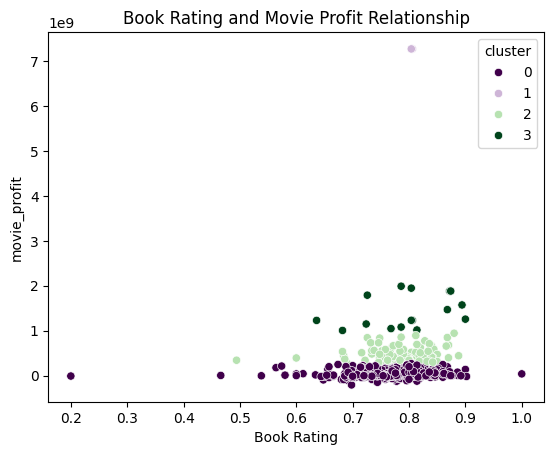

In [39]:
sns.scatterplot(
    data = df,
    x = "Book Rating",
    y = "movie_profit",
    hue = "cluster",
    palette = "PRGn"
)
plt.title("Book Rating and Movie Profit Relationship")

Text(0.5, 1.0, 'Movie Profit Clusters')

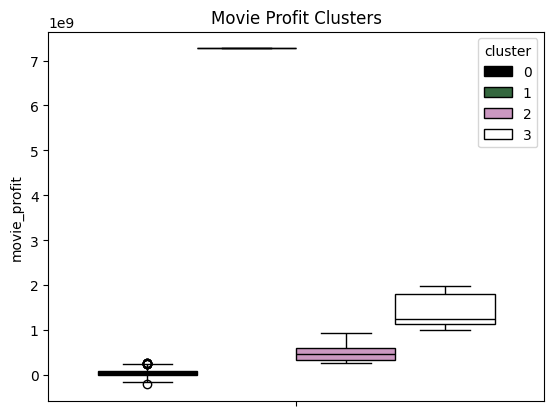

In [33]:
sns.boxplot(
    data = df,
    y = "movie_profit",
    hue = df["cluster"],
    palette = "cubehelix"
)
plt.title("Movie Profit Clusters")

Text(0.5, 1.0, 'Movie Release Date and Movie Profit Relationship')

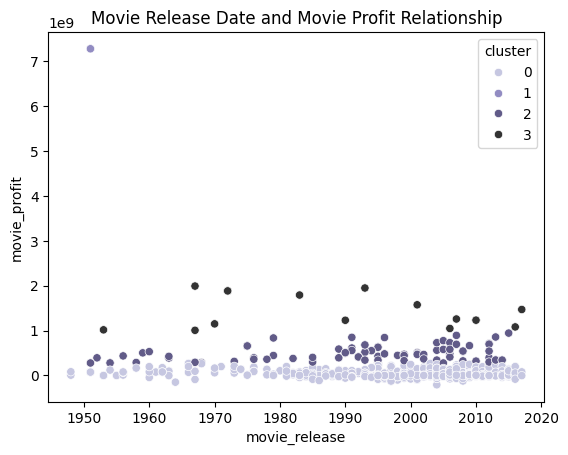

In [40]:
sns.scatterplot(
    data = df,
    x = "movie_release",
    y = "movie_profit",
    hue = "cluster",
    palette = "Purples_d"
)
plt.title("Movie Release Date and Movie Profit Relationship")